In [9]:
!pip -q install shap
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import shap
import numpy as np

shap.initjs()

# Caricamento del dataset Diabetes
# Il dataset contiene:
# X: features (numeriche)
# y: target (continuo) -> progressione della malattia un anno dopo la baseline

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target



In [10]:
# Dividere il dataset in set di addestramento e test
# random_state = 42 per riproducibilità
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
# Addestramento del modello Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Valutazione del modello
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score sul test set:", r2)
print("MSE sul test set:", mse)


R2 Score sul test set: 0.4428225673999313
MSE sul test set: 2952.0105887640448


In [12]:
# Utilizzo di SHAP per spiegare le previsioni del modello
# Creiamo un Explainer basato sul modello addestrato
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [13]:
# Selezione di un'istanza di test casuale
# Ci assicuriamo che l'istanza sia nei limiti del test set
instance_idx = np.random.randint(0, X_test.shape[0])
instance = X_test[instance_idx:instance_idx+1]

In [14]:
# Spiegazione delle previsioni del modello per l'istanza selezionata
# shap_values è un array che contiene l'effetto di ciascuna feature
# sulla predizione del modello
single_shap_values = explainer.shap_values(instance)

In [17]:
# Visualizzazione delle spiegazioni usando diverse metodologie SHAP e diverse visualizzazioni
shap.initjs()
# Force plot per l'istanza singola: mostra come ogni feature influisce sulla predizione
shap.force_plot(explainer.expected_value, single_shap_values, instance, feature_names=diabetes.feature_names)


In [19]:
shap.initjs()
# Force plot globale (per avere una visione d'insieme)
shap.force_plot(explainer.expected_value, shap_values, X_test, feature_names=diabetes.feature_names)


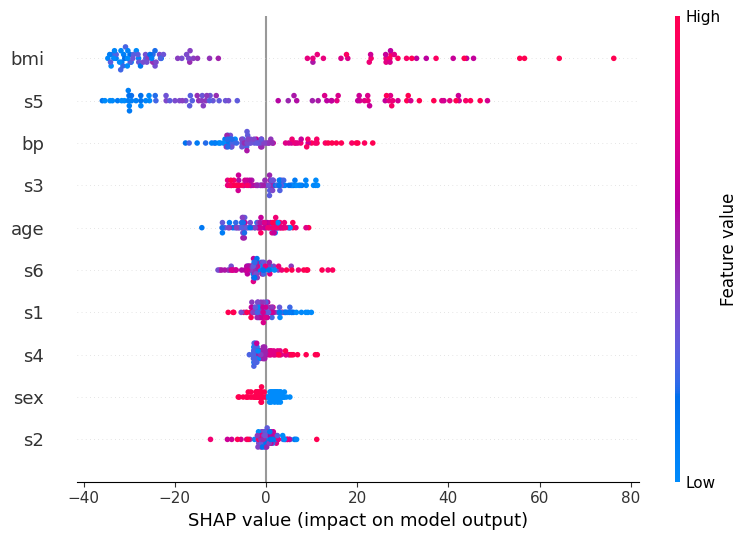

In [20]:
shap.initjs()
# Summary plot: visualizza l'importanza delle feature a livello di test set
shap.summary_plot(shap_values, X_test, feature_names=diabetes.feature_names)


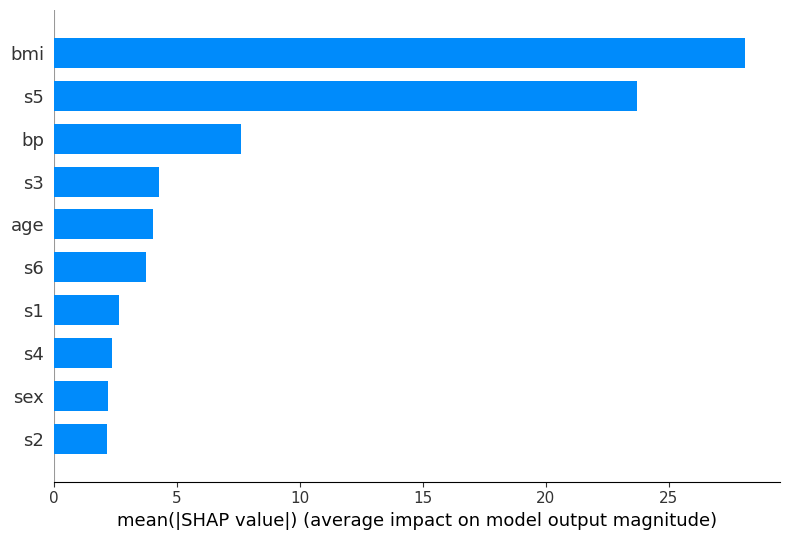

In [22]:
# Bar plot: visualizza l'effetto medio delle feature sul target
shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=diabetes.feature_names)